# differential-expression-analysis-top10
6.7.25

Want to repeat the DA analysis after introducing additional missingness into the top-10 DA proteins 
and then imputing them with various methods. 

In [1]:
import pandas as pd
import numpy as np 
from tqdm import tqdm
from Bio import SeqIO
from scipy import stats
from adjustText import adjust_text

import matplotlib.pyplot as plt
import seaborn as sns

# plotting templates
sns.set(context="talk", style="ticks") 
pal = sns.color_palette("tab10")

#### Configs

In [2]:
# The unimputed joint quants matrix
joint_fname="../results/panCan-unimputed-starting-point.csv"

# The imputed quants matrices
ccrcc_knn_path="../results/CCRCC-quants-kNN-imputed.csv"
ccrcc_unimputed_path="../data/CCRCC-quants-top10-sim.csv"
ccrcc_lupine_path="../results/lupine-ensemble-CCRCC-top10.csv"
ccrcc_missforest_path="../results/CCRCC-quants-missForest-imputed.csv"

# The metadata dictionary, previously created
meta_path="/net/noble/vol2/home/lincolnh/code/2023_harris_deep_impute/results/2024-05-10_metadata_mapping/meta-dict.csv"

cohort="CCRCC"

pres_frac_thresh=0.5

#### Functions

In [3]:
def stat_test(tumor_quants, nontumor_quants, indices):
    """
    Performs the statistical testing. Wilcoxon rank-sum testing for differential
    abundance, and then FDR control with Benjamani-Hochberg. 

    Parameters
    ----------
    tumor_quants, nontumor_quants : `np.ndarray`, 
        Two arrays of protein quants, for the tumor and non-tumor samples, 
        respectively. 
    indices: list, 
        The list of dataframe indicies. Should correspond to HGNC IDs for 
        each protein. 
    
    Returns
    ----------
    df : `pandas.DataFrame`, 
        A dataframe containing the stat. test results for every protein
    """
    def bh_adjustment(pvals):
        """
        Performs the Benjamini-Hochberg procedure
        for p-value ADJUSTMENT. So this means we actually 
        return a list of corrected p-values, not just a 
        boolean specifying which p-values to keep per the
        FDR controlled at some threshold. 
        
        Parameters
        ----------
        pvals : np.ndarray, 
            The sorted list of uncorrected p-values. Sorted
            from smallest to largest
    
        Returns
        -----------
        pvals_adjusted : list, 
            A list of the BH adjusted p-values
        """
        pvals_adjusted = []
    
        for i in range(0, len(pvals)):
            rank = i + 1
            curr_pval = pvals[i]
            pval_adj = (curr_pval * len(pvals)) / rank
            pvals_adjusted.append(pval_adj)        
    
        return pvals_adjusted

    pvals = []
    
    # Perform the Wilcoxon rank-sum testing
    for i in range(0, tumor_quants.shape[0]):
        stat, pval = stats.ranksums(tumor_quants[i], nontumor_quants[i], nan_policy="omit")
        pvals.append(pval)
    
    # Init a dataframe to hold the p-values and adjusted p-values
    df = pd.DataFrame(columns = ["HGNC", "pval", "adj_pval", "orig_idx"])
    df["HGNC"] = indices
    df["pval"] = pvals
    
    # Sort by uncorrected p-values
    df = df.sort_values(by="pval")
    
    # Do the Benjamani-Hochberg adjustment
    pvals_corrected = bh_adjustment(np.array(df["pval"]))
    df["adj_pval"] = pvals_corrected
    df["orig_idx"] = list(df.index)
    
    # Return to the initial order
    df = df.sort_values(by="orig_idx")
    
    # Get the FDR
    fdr = -np.log10(np.array(df["adj_pval"]))
    df["FDR"] = fdr

    return df

#### Read in the imputed quants
And the unimputed quants. And subset the Lupine-imputed quants mat. Keep in mind that this unimputed matrix has 40% of additional missing values in the top-10 proteins for the current cohort. 

In [4]:
unimputed_mat = pd.read_csv(ccrcc_unimputed_path, index_col=0)
knn_mat = pd.read_csv(ccrcc_knn_path, index_col=0)
knn_mat.index = unimputed_mat.index
knn_mat.columns = unimputed_mat.columns

# The INTACT unimputed matrix....doesn't have the 40% additional missingess
panCan_unimputed = pd.read_csv(joint_fname, index_col=0)
panCan_unimputed_cohort = panCan_unimputed[unimputed_mat.columns]

lupine_mat = pd.read_csv(ccrcc_lupine_path, index_col=0)
lupine_mat.index = panCan_unimputed.index
lupine_mat.columns = panCan_unimputed.columns
lupine_mat = lupine_mat[unimputed_mat.columns]

mf_mat = pd.read_csv(ccrcc_missforest_path, index_col=0).T
mf_mat.index = unimputed_mat.index
mf_mat.columns = unimputed_mat.columns

print(unimputed_mat.shape)
print(knn_mat.shape)
print(lupine_mat.shape)
print(panCan_unimputed_cohort.shape)
print(mf_mat.shape)

(18162, 194)
(18162, 194)
(18162, 194)
(18162, 194)
(18162, 194)


#### Read in the metadata
And subset down to only the cohort of interest. 
And get IDs for tumor vs non-tumor samples. 

In [5]:
# Might need `index_col=0` here
meta_dict = pd.read_csv(meta_path)
meta_dict = meta_dict[meta_dict["cohort"] == cohort]
meta_dict = meta_dict.reset_index(drop=True)

tumor_samples_meta = meta_dict[(meta_dict["sample_type"] == "Primary Tumor") | (meta_dict["sample_type"] == "Tumor")]
nontumor_samples_meta = meta_dict[(meta_dict["sample_type"] != "Primary Tumor") & (meta_dict["sample_type"] != "Tumor")]

tumor_IDs = list(tumor_samples_meta["aliquot_ID"])
nontumor_IDs = list(nontumor_samples_meta["aliquot_ID"])

print(len(tumor_IDs))
print(len(nontumor_IDs))

110
84


#### Exponentiate to get the original, untransformed intensities

In [6]:
panCan_unimputed_cohort = np.power(2, panCan_unimputed_cohort)
knn_mat = np.power(2, knn_mat)
lupine_mat = np.power(2, lupine_mat)
mf_mat = np.power(2, mf_mat)

#### Get quants matrices for tumor and non-tumor samples 

In [7]:
unimputed_tumor_quants = np.array(panCan_unimputed_cohort[tumor_IDs])
unimputed_nontumor_quants = np.array(panCan_unimputed_cohort[nontumor_IDs])

knn_tumor_quants = np.array(knn_mat[tumor_IDs])
knn_nontumor_quants = np.array(knn_mat[nontumor_IDs])

lupine_tumor_quants = np.array(lupine_mat[tumor_IDs])
lupine_nontumor_quants = np.array(lupine_mat[nontumor_IDs])

mf_tumor_quants = np.array(mf_mat[tumor_IDs])
mf_nontumor_quants = np.array(mf_mat[nontumor_IDs])

#### Do the Wilcoxon rank-sum and BH correction
For all three methods

In [8]:
prot_IDs = list(panCan_unimputed_cohort.index)

unimputed_stats = stat_test(unimputed_tumor_quants, unimputed_nontumor_quants, prot_IDs)
knn_stats = stat_test(knn_tumor_quants, knn_nontumor_quants, prot_IDs)
lupine_stats = stat_test(lupine_tumor_quants, lupine_nontumor_quants, prot_IDs)
mf_stats = stat_test(mf_tumor_quants, mf_nontumor_quants, prot_IDs)

/net/noble/vol2/home/lincolnh/miniconda3/envs/deep-impute/lib/python3.9/site-packages/scipy/stats/_stats_py.py:9154: RuntimeWarning: invalid value encountered in scalar divide
  z = (s - expected) / np.sqrt(n1*n2*(n1+n2+1)/12.0)


#### Get the log fold changes 

In [9]:
unimputed_tumor_means = np.nanmean(unimputed_tumor_quants, axis=1)
unimputed_nontumor_means = np.nanmean(unimputed_nontumor_quants, axis=1)
unimputed_fc = np.log2(unimputed_tumor_means / unimputed_nontumor_means)

knn_tumor_means = np.nanmean(knn_tumor_quants, axis=1)
knn_nontumor_means = np.nanmean(knn_nontumor_quants, axis=1)
knn_fc = np.log2(knn_tumor_means / knn_nontumor_means)

lupine_tumor_means = np.nanmean(lupine_tumor_quants, axis=1)
lupine_nontumor_means = np.nanmean(lupine_nontumor_quants, axis=1)
lupine_fc = np.log2(lupine_tumor_means / lupine_nontumor_means)

mf_tumor_means = np.nanmean(mf_tumor_quants, axis=1)
mf_nontumor_means = np.nanmean(mf_nontumor_quants, axis=1)
mf_fc = np.log2(mf_tumor_means / mf_nontumor_means)

/tmp/ipykernel_744609/2359004165.py:1: RuntimeWarning: Mean of empty slice
  unimputed_tumor_means = np.nanmean(unimputed_tumor_quants, axis=1)
/tmp/ipykernel_744609/2359004165.py:2: RuntimeWarning: Mean of empty slice
  unimputed_nontumor_means = np.nanmean(unimputed_nontumor_quants, axis=1)


#### Create an aggregated stats dataframe 

In [15]:
cols=["HGNC", 
      "qval_unimputed", "qval_lupine", "qval_knn", "qval_mf", 
      "FC_unimputed", "FC_lupine", "FC_knn", "FC_mf",
      "FDR_unimputed", "FDR_lupine", "FDR_knn", "FDR_mf",
]

stats_df = pd.DataFrame(columns=cols)
stats_df["HGNC"] = unimputed_stats["HGNC"]

stats_df["qval_unimputed"] = unimputed_stats["adj_pval"]
stats_df["FC_unimputed"] = unimputed_fc
stats_df["FDR_unimputed"] = unimputed_stats["FDR"]

stats_df["qval_lupine"] = lupine_stats["adj_pval"]
stats_df["FC_lupine"] = lupine_fc
stats_df["FDR_lupine"] = lupine_stats["FDR"]

stats_df["qval_knn"] = knn_stats["adj_pval"]
stats_df["FC_knn"] = knn_fc
stats_df["FDR_knn"] = knn_stats["FDR"]

stats_df["qval_mf"] = mf_stats["adj_pval"]
stats_df["FC_mf"] = mf_fc
stats_df["FDR_mf"] = mf_stats["FDR"]

#### Create a dictionary to hold the top-10 DE proteins from Savage et al. 2024

In [16]:
ccrcc_top10 = ["TBXAS1", "PKN1", "PYGL", "P4HB", "ITGA5", "PPAT", "CAD", "TRIO", "LDHA", "ACLY"]
luad_top10 = ["P4HB", "LDHA", "CDK12", "RANBP2", "SF3B1", "WDR5", "TOP1", "IARS1", "LARS1", "EEF2"]
coad_top10 = ["HSP90AB1", "CAD", "SLC3A2", "RANBP2", "PRPF4B", "TOP1", "SF3B1", "IARS1", "MARS1", "TOP2A"]
hgsc_top10 = ["ERP44", "APEX1", "HSP90AB1", "HSP90AA1", "PARP1", "TOP1", "HSP90B1", "MARS1", "IARS1" "SF3B1"]
hnscc_top10 = ["PTK7", "SLC38A1", "PTPN12", "FKBP9", "PAK2", "ITPR3", "PTPN1", "NMT1", "ATP6V1C1", "TOP1"]
pdac_top10 = ["ITGB4", "QSOX1", "ITPR3", "MET", "AEBP1", "NUCB1", "ITGAV", "LDHA", "GRK2", "LGALS3BP"]
lscc_top10 = ["GART", "CAD", "PARP1", "PPAT", "CDK12", "TOP1", "CDK9", "SF3B1", "EEF2", "RRM2"]
ucec_top10 = ["TACSTD2", "PIK3CB", "IL4I1", "KDM3A", "PPIF", "PTPRF", "PAK1", "IDE", "CSNK1A1", "MARS1"]

savage_mapper = {}

savage_mapper["CCRCC"] = ccrcc_top10
savage_mapper["LUAD"] = luad_top10
savage_mapper["COAD"] = coad_top10
savage_mapper["HGSC"] = hgsc_top10
savage_mapper["HNSCC"] = hnscc_top10
savage_mapper["PDAC"] = pdac_top10
savage_mapper["LSCC"] = lscc_top10
savage_mapper["UCEC"] = ucec_top10

#### Get the stats for the top-10 DA proteins 
Not totally sure how to visualize this. 

In [17]:
keep = [x in savage_mapper["CCRCC"] for x in stats_df["HGNC"]]
cohort_stats_df = stats_df[keep]
#cohort_stats_df.head(4)

#### Create an augmented volcano plot

In [18]:
# fig, ax = plt.subplots(1, 1, figsize=(5,5))

# # THE BASE SCATTER PLOT
# sns.scatterplot(
#     data=stats_df,
#     x="FC_unimputed", 
#     y="FDR_unimputed", 
#     alpha=0.01, 
#     linewidth=0.1,
#     color="#7f7f7f",
#     rasterized=True,
#     ax=ax,
# )
# # THE UNIMPUTED TOP-10 SCATTER PLOT
# sns.scatterplot(
#     data=cohort_stats_df,
#     x="FC_unimputed", 
#     y="FDR_unimputed", 
#     alpha=0.7, 
#     linewidth=0.1,
#     color="#1f77b4",
#     rasterized=True,
#     ax=ax,
#     label="Unimputed",
# )
# # THE LUPINE-IMPUTED TOP-10 SCATTER PLOT
# sns.scatterplot(
#     data=cohort_stats_df,
#     x="FC_lupine", 
#     y="FDR_lupine", 
#     alpha=0.7, 
#     linewidth=0.1,
#     color="#ff7f0e",
#     rasterized=True,
#     ax=ax,
#     label="Lupine (40% missing)",
# )
# # THE KNN-IMPUTED TOP-10 SCATTER PLOT
# sns.scatterplot(
#     data=cohort_stats_df,
#     x="FC_knn", 
#     y="FDR_knn", 
#     alpha=0.7, 
#     linewidth=0.1,
#     color="#2ca02c",
#     rasterized=True,
#     ax=ax,
#     label="kNN (40% missing)",
# )
# ax.set_title(cohort, pad=16, size=24)
# ax.set_xlabel("Log$_{2}$ FC", labelpad=10)
# ax.set_ylabel("-Log$_{10}$ p-value", labelpad=10)

# ax.axvline(0 ,color="black", linestyle="--", alpha=0.4, lw=1.25)
# ax.axhline(2, color="black", linestyle="--", alpha=0.4, lw=1.25)

# plt.legend(title="", edgecolor="k", prop={'size': 12}, 
#            loc="upper right", bbox_to_anchor=(1.7, 1.0),
# )

# plt.show()

#### What if we plotted this as three panels? 

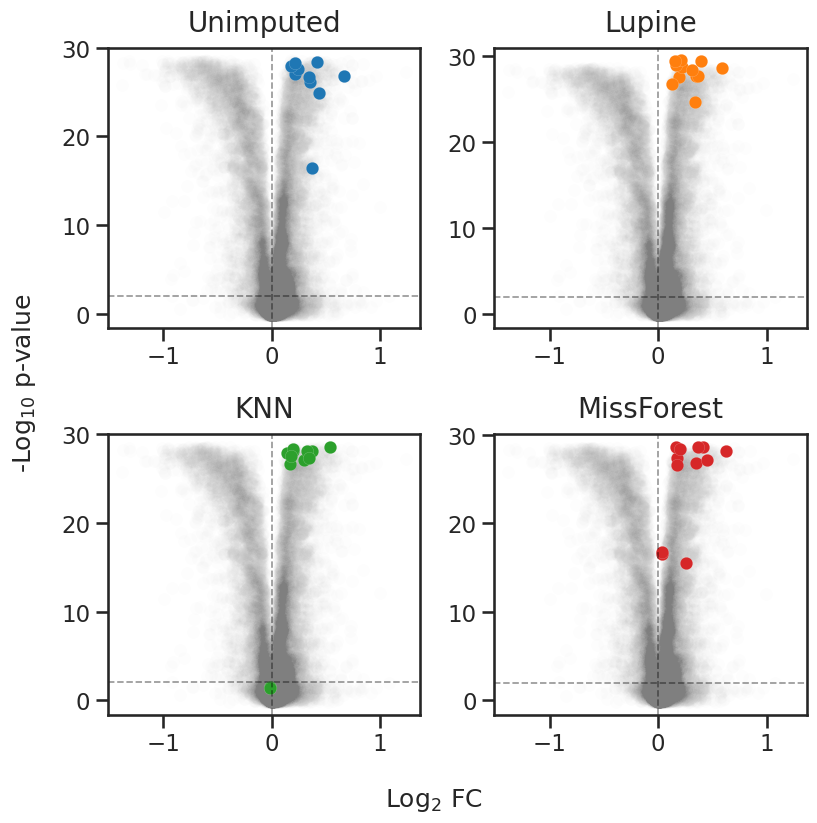

In [41]:
fig, ax = plt.subplots(2,2, figsize=(8,8))

# THE BASE SCATTER PLOT
sns.scatterplot(
    data=stats_df,
    x="FC_unimputed", 
    y="FDR_unimputed", 
    alpha=0.01, 
    linewidth=0.1,
    color="#7f7f7f",
    rasterized=True,
    ax=ax[0,0],
)
# THE UNIMPUTED TOP-10 SCATTER PLOT
sns.scatterplot(
    data=cohort_stats_df,
    x="FC_unimputed", 
    y="FDR_unimputed", 
    alpha=1.0, 
    linewidth=0.1,
    color="#1f77b4",
    rasterized=True,
    ax=ax[0,0],
)
ax[0,0].set_title("Unimputed", pad=12, size=20)
ax[0,0].set_xlabel("")
ax[0,0].set_ylabel("")
ax[0,0].axvline(0 ,color="black", linestyle="--", alpha=0.4, lw=1.25)
ax[0,0].axhline(2, color="black", linestyle="--", alpha=0.4, lw=1.25)

# THE BASE SCATTER PLOT
sns.scatterplot(
    data=stats_df,
    x="FC_unimputed", 
    y="FDR_unimputed", 
    alpha=0.01, 
    linewidth=0.1,
    color="#7f7f7f",
    rasterized=True,
    ax=ax[0,1],
)
# THE LUPINE-IMPUTED TOP-10 SCATTER PLOT
sns.scatterplot(
    data=cohort_stats_df,
    x="FC_lupine", 
    y="FDR_lupine", 
    alpha=1.0, 
    linewidth=0.1,
    color="#ff7f0e",
    rasterized=True,
    ax=ax[0,1],
)
ax[0,1].set_title("Lupine", pad=12, size=20)
ax[0,1].set_xlabel("")
ax[0,1].set_ylabel("")
ax[0,1].axvline(0 ,color="black", linestyle="--", alpha=0.4, lw=1.25)
ax[0,1].axhline(2, color="black", linestyle="--", alpha=0.4, lw=1.25)

# THE BASE SCATTER PLOT
sns.scatterplot(
    data=stats_df,
    x="FC_unimputed", 
    y="FDR_unimputed", 
    alpha=0.01, 
    linewidth=0.1,
    color="#7f7f7f",
    rasterized=True,
    ax=ax[1,0],
)
# THE KNN-IMPUTED TOP-10 SCATTER PLOT
sns.scatterplot(
    data=cohort_stats_df,
    x="FC_knn", 
    y="FDR_knn", 
    alpha=1.0, 
    linewidth=0.1,
    color="#2ca02c",
    rasterized=True,
    ax=ax[1,0],
)
ax[1,0].set_title("KNN", pad=12, size=20)
ax[1,0].set_xlabel("")
ax[1,0].set_ylabel("")
ax[1,0].axvline(0 ,color="black", linestyle="--", alpha=0.4, lw=1.25)
ax[1,0].axhline(2, color="black", linestyle="--", alpha=0.4, lw=1.25)

# THE BASE SCATTER PLOT
sns.scatterplot(
    data=stats_df,
    x="FC_unimputed", 
    y="FDR_unimputed", 
    alpha=0.01, 
    linewidth=0.1,
    color="#7f7f7f",
    rasterized=True,
    ax=ax[1,1],
)
# THE MISSFOREST-IMPUTED TOP-10 SCATTER PLOT
sns.scatterplot(
    data=cohort_stats_df,
    x="FC_mf", 
    y="FDR_mf", 
    alpha=1.0, 
    linewidth=0.1,
    color="#d62728",
    rasterized=True,
    ax=ax[1,1],
)
ax[1,1].set_title("MissForest", pad=12, size=20)
ax[1,1].set_xlabel("")
ax[1,1].set_ylabel("")
ax[1,1].axvline(0 ,color="black", linestyle="--", alpha=0.4, lw=1.25)
ax[1,1].axhline(2, color="black", linestyle="--", alpha=0.4, lw=1.25)

fig.text(-0.03, 0.5, "-Log$_{10}$ p-value", va="center", rotation="vertical", size=18)
fig.text(0.5, -0.03, "Log$_{2}$ FC", ha="center", size=18)
fig.tight_layout()

plt.show()
#plt.savefig("../figures/top10-DA-v2.png", bbox_inches="tight", dpi=250)
#plt.savefig("../figures/top10-DA-v2.pdf", bbox_inches="tight", dpi=300)